### Кастомная CNN (baseline)

Самостоятельная реализация MiniResNet, обучение как у baseline ResNet18: Adam + StepLR, 10 эпох, без аугментаций.

импорт библиотек

In [1]:
from common import *

Подготовка данных для обучения:
- настройка параметров обчения
- настройка наборов данных для обучения и тестирования
- настройка загрузчиков

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка информации о разбиении набора данных
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # список классов
BATCH_SIZE = cfg["batch_size"] # размер батча
IMG_SIZE = cfg["img_size"] # размер изображения
train_indices = cfg["train_indices"] # индексы тренировочного набора
val_indices = cfg["val_indices"] # индексы валидационного набора
SEED = cfg["seed"] # seed для повторяемости

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform) # создание тренировочного набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание валидационного набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание тестового набора

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # изменение списка образцов тренировочного набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # изменение списка образцов валидационного набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тренировочного набора
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для валидационного набора
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тестового набора

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


Функция для обучения модели

In [ ]:
def train_custom(model, model_name, train_loader, val_loader, test_loader, epochs, optimizer, scheduler, criterion, device=DEVICE, use_amp=True):
    """ Функция обучения модели """
    model = model.to(device) # перенос модели на устройство
    scaler = torch.amp.GradScaler("cuda") if (use_amp and device.type == "cuda") else None # создание масштабирующего устройства для градиентов
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # инициализация истории обучения

    for epoch in range(epochs): # цикл по эпохам обучения
        model.train() # перевод модели в режим обучения
        running_loss = 0.0 # инициализация переменной для хранения суммы потерь
        all_preds, all_labels = [], [] # инициализация списков для хранения предсказаний и меток
        for images, labels in train_loader: # цикл по батчам тренировочного набора
            images, labels = images.to(device), labels.to(device) # перенос изображений и меток на устройство
            optimizer.zero_grad() # обнуление градиентов
            if scaler: # проверка на использование масштабирующего устройства
                with torch.amp.autocast("cuda"): # перевод модели в режим масштабирующего устройства
                    outputs = model(images) # получение предсказаний
                    loss = criterion(outputs, labels) # вычисление потерь
                scaler.scale(loss).backward() # масштабирование градиентов
                scaler.step(optimizer) # обновление весов
                scaler.update() # обновление масштаба
            else: # если не используется масштабирующее устройство
                outputs = model(images) # получение предсказаний
                loss = criterion(outputs, labels) # вычисление потерь
                loss.backward() # обратная прогонка
                optimizer.step() # обновление весов
            running_loss += loss.item() * images.size(0) # суммирование потерь
            _, preds = torch.max(outputs, 1) # получение предсказаний
            all_preds.extend(preds.cpu().numpy()) # добавление предсказаний в список
            all_labels.extend(labels.cpu().numpy()) # добавление меток в список
        train_loss = running_loss / len(train_loader.dataset) # вычисление средней потери
        train_acc = accuracy_score(all_labels, all_preds) # вычисление точности
        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # оценка модели на валидационном наборе
        if scheduler is not None: # проверка на использование планировщика
            scheduler.step() # обновление планировщика
        history["train_loss"].append(train_loss) # добавление потери на тренировочном наборе в историю
        history["val_loss"].append(val_loss) # добавление потери на валидационном наборе в историю
        history["train_acc"].append(train_acc) # добавление точности на тренировочном наборе в историю
        history["val_acc"].append(val_acc) # добавление точности на валидационном наборе в историю
        
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Bal Acc: {val_bal_acc:.4f}, Val F1: {val_f1:.4f}")

    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device) # оценка модели на тестовом наборе
    # вывод метрик на тестовом наборе
    print(f"\n{model_name} - TEST")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro-F1: {test_f1:.4f}")

    # построение матрицы ошибок
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout(); plt.show()

    # построение графиков потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # вывод отчета о классификации
    print(f"\n{model_name} - Classification report:")
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

    # возвращение модели и истории обучения
    return model, {
        "model": model_name, "test_acc": test_acc, "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1, "history": history, "confusion_matrix": cm.tolist(),
    }

Создание составных частей модели

In [ ]:
class ConvBlock(nn.Module): # блок свертки
    def __init__(self, in_ch, out_ch, stride=1): # инициализация
        super().__init__() # вызов инициализации родительского класса
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False), # свертка
            nn.BatchNorm2d(out_ch), # нормализация
            nn.ReLU(inplace=True), # ReLU
        ) # сеть
    def forward(self, x): # прямой проход
        return self.net(x) # возвращение результата


class ResidualBlock(nn.Module): # блок остаточной связи
    def __init__(self, in_ch, out_ch, stride=2): # инициализация
        super().__init__() # вызов инициализации родительского класса
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False) # свертка
        self.bn1 = nn.BatchNorm2d(out_ch) # нормализация
        self.relu = nn.ReLU(inplace=True) # ReLU
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False) # свертка
        self.bn2 = nn.BatchNorm2d(out_ch) # нормализация
        self.down = None # остаточная связь
        if stride != 1 or in_ch != out_ch: # проверка на изменение размера
            self.down = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False), # свертка
                nn.BatchNorm2d(out_ch), # нормализация
            ) # остаточная связь

    def forward(self, x): # прямой проход
        identity = x # остаточная связь
        x = self.relu(self.bn1(self.conv1(x))) # ReLU
        x = self.bn2(self.conv2(x)) # свертка
        if self.down is not None: # проверка на остаточную связь
            identity = self.down(identity) # остаточная связь
        x = self.relu(x + identity) # ReLU
        return x # возвращение результата


class CustomMiniResNet(nn.Module): # кастомная CNN с нуля (MiniResNet): residual-блоки без torchvision.
    """Кастомная CNN с нуля (MiniResNet): residual-блоки без torchvision."""
    def __init__(self, num_classes=4): # инициализация
        super().__init__() # вызов инициализации родительского класса
        self.stem = ConvBlock(3, 32, stride=1) # свертка
        self.layer1 = ResidualBlock(32, 64, stride=2) # блок остаточной связи
        self.layer2 = ResidualBlock(64, 128, stride=2) # блок остаточной связи
        self.layer3 = ResidualBlock(128, 256, stride=2) # блок остаточной связи
        self.layer4 = ResidualBlock(256, 512, stride=2) # блок остаточной связи
        self.pool = nn.AdaptiveAvgPool2d(1) # пуллинг
        self.dropout = nn.Dropout(0.1) # dropout
        self.fc = nn.Linear(512, num_classes) # линейный слой

    def forward(self, x): # прямой проход
        x = self.stem(x) # свертка
        x = self.layer1(x) # блок остаточной связи
        x = self.layer2(x) # блок остаточной связи
        x = self.layer3(x) # блок остаточной связи
        x = self.layer4(x) # блок остаточной связи
        x = self.pool(x).flatten(1) # пуллинг
        x = self.dropout(x) # dropout
        return self.fc(x) # линейный слой

Обучение модели

Epoch 1/10 - Train Loss: 0.6970, Train Acc: 0.7208 - Val Loss: 0.7914, Val Acc: 0.7520, Val Bal Acc: 0.7521, Val F1: 0.7513
Epoch 2/10 - Train Loss: 0.3781, Train Acc: 0.8637 - Val Loss: 0.2691, Val Acc: 0.9121, Val Bal Acc: 0.9124, Val F1: 0.9100
Epoch 3/10 - Train Loss: 0.2888, Train Acc: 0.8976 - Val Loss: 0.3950, Val Acc: 0.8514, Val Bal Acc: 0.8513, Val F1: 0.8509
Epoch 4/10 - Train Loss: 0.2002, Train Acc: 0.9351 - Val Loss: 0.1196, Val Acc: 0.9598, Val Bal Acc: 0.9600, Val F1: 0.9598
Epoch 5/10 - Train Loss: 0.1754, Train Acc: 0.9395 - Val Loss: 0.1021, Val Acc: 0.9679, Val Bal Acc: 0.9680, Val F1: 0.9679
Epoch 6/10 - Train Loss: 0.1602, Train Acc: 0.9459 - Val Loss: 0.0951, Val Acc: 0.9694, Val Bal Acc: 0.9695, Val F1: 0.9694
Epoch 7/10 - Train Loss: 0.1385, Train Acc: 0.9552 - Val Loss: 0.0870, Val Acc: 0.9734, Val Bal Acc: 0.9735, Val F1: 0.9735
Epoch 8/10 - Train Loss: 0.1373, Train Acc: 0.9544 - Val Loss: 0.0882, Val Acc: 0.9714, Val Bal Acc: 0.9715, Val F1: 0.9715
Epoch 9/

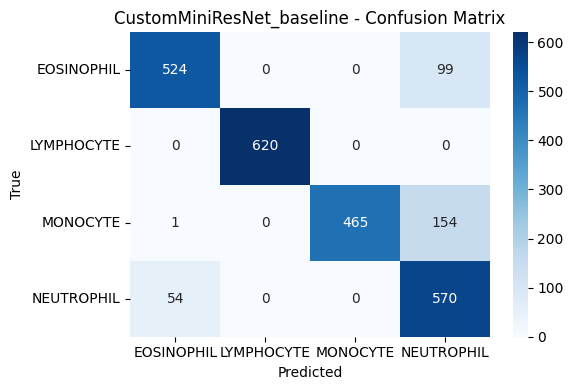

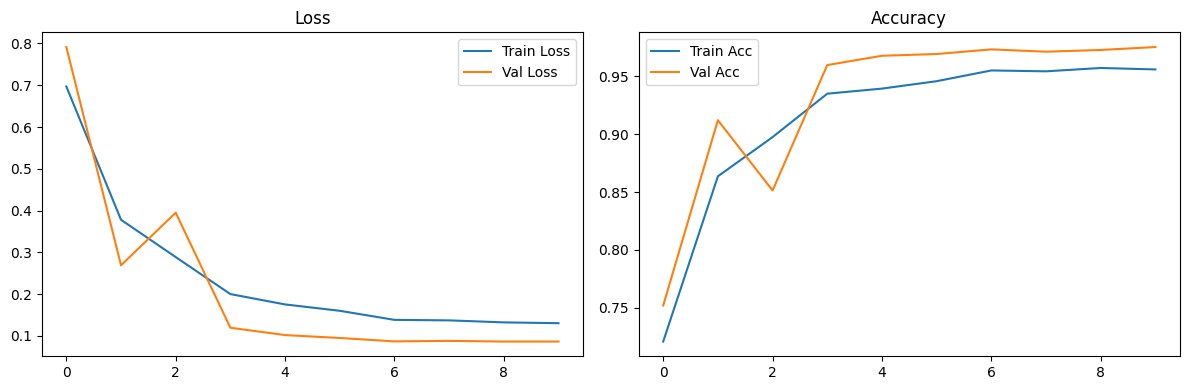


CustomMiniResNet_baseline - Classification report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.91      0.84      0.87       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.69      0.91      0.79       624

    accuracy                           0.88      2487
   macro avg       0.90      0.88      0.88      2487
weighted avg       0.90      0.88      0.88      2487

Веса сохранены: outputs/custom_cnn_baseline.pth


In [ ]:
set_seed(SEED)
model = CustomMiniResNet(num_classes=len(CLASS_NAMES)) # создание модели
optimizer = optim.Adam(model.parameters(), lr=1e-3) # оптимизатор
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) # планировщик
criterion = nn.CrossEntropyLoss() # критерий

model, result = train_custom( 
    model, "CustomMiniResNet_baseline",
    train_loader, val_loader, test_loader,
    epochs=10, optimizer=optimizer, scheduler=scheduler, criterion=criterion, device=DEVICE,
) # обучение модели

os.makedirs("outputs", exist_ok=True)
torch.save(model.state_dict(), "outputs/custom_cnn_baseline.pth") # сохранение весов
print("Веса сохранены: outputs/custom_cnn_baseline.pth") # вывод сообщения

Кастомная CNN с остаточными соединениями, обученная с нуля, достигла Accuracy 0.8762, Balanced Accuracy 0.8761, Macro-F1 0.8792. Это выше, чем у предобученного ResNet18 baseline (0.8544), что на первый взгляд неожиданно. 

Кастомная архитектура более компактна (4 блока ResidualBlock), что снижает риск переобучения на малом датасете. Кривая обучения показала быстрый рост val Accuracy (0.752 - 0.975) с типичным провалом на эпохе 3, после которого модель стабилизировалась. Функция потерь монотонно убывала (0.697 - 0.130).

In [ ]:
all_results = load_results()
all_results["CustomMiniResNet_baseline"] = result # добавление результата в словарь

df_cosine = pd.DataFrame([result]) # создание DataFrame из результата
baseline_models = pd.DataFrame([ # создание DataFrame из baseline моделей
    all_results["baseline_resnet18"], # добавление baseline ResNet18 в DataFrame
    all_results["baseline_swin"], # добавление baseline Swin в DataFrame
])

df_compare = pd.concat([baseline_models, df_cosine], ignore_index=True) # создание DataFrame из baseline моделей и CustomMiniResNet_baseline

print("Baseline vs CustomMiniResNet_baseline:")
display(df_compare[["model", "test_acc", "test_bal_acc", "test_f1_macro"]]) # вывод результата
save_results(all_results) # сохранение результата

Baseline vs CustomMiniResNet_baseline:


,model,test_acc,test_bal_acc,test_f1_macro
0,ResNet18,0.854443,0.854462,0.858832
1,Swin-T,0.880177,0.880147,0.883016
2,CustomMiniResNet_baseline,0.876156,0.876138,0.879215


Результаты сохранены в outputs/experiment_results.pkl


Имплементация продемонстрировала конкурентоспособность ResNet18 в условиях небольшого датасета с выраженными локальными признаками, подтверждая, что для задачи классификации клеток крови CNN-архитектура хорошо подходит даже при обучении с нуля.